# Notebook 1: The Problem
## Collatz Conjecture — Beautiful Dead Ends

---

### Why I'm here

This is not an attempt to solve the Collatz Conjecture. I want to be clear about that from the start, because I think there's something dishonest about framing exploratory mathematical reasoning as though it's heading somewhere it isn't.

What I'm trying to do instead is think carefully and systematically about an unsolved problem — to follow the reasoning as far as I can, document what's interesting along the way, and be honest when I hit a wall. Hitting the wall is, in a sense, the point. Understanding *why* a problem is hard is itself a form of progress.

This notebook is the foundation. I want to state the problem precisely, get my hands dirty with the actual sequences, and ask the first questions. Later notebooks will chase those questions.

---

### The problem, stated precisely

Take any positive integer $n$. Apply the following rule repeatedly:

$$
f(n) = \begin{cases} n/2 & \text{if } n \text{ is even} \\ 3n + 1 & \text{if } n \text{ is odd} \end{cases}
$$

The **Collatz Conjecture** (also known as the $3n+1$ problem, the Syracuse problem, and several other names) states:

> For every positive integer $n$, repeated application of $f$ will eventually reach 1.

Once you reach 1, the sequence cycles: $1 \to 4 \to 2 \to 1 \to \ldots$ So 1 is the absorbing state.

That's it. That's the whole problem. It has been verified computationally for all $n$ up to at least $2^{68}$ (roughly $2.95 \times 10^{20}$). It has not been proven in general. Paul Erdős said of it: *"Mathematics is not yet ready for such problems."*

I find that both humbling and compelling.

---

### A note on terminology I'll use throughout

The **Collatz sequence** starting at $n$ is the sequence $n, f(n), f(f(n)), \ldots$ until we reach 1.

The **stopping time** (or total stopping time) of $n$ is the number of steps to reach 1.

A **peak** is the maximum value the sequence reaches before descending to 1.

I'll use these terms consistently. Let's start computing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Set a consistent style for all notebooks in this project
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#444',
    'axes.labelcolor': '#ccc',
    'xtick.color': '#888',
    'ytick.color': '#888',
    'text.color': '#ccc',
    'grid.color': '#2a2a2a',
    'grid.linestyle': '-',
    'axes.grid': True,
    'font.family': 'monospace',
})

ACCENT = '#e05c5c'   # a muted red — feels right for a dead end
SUBTLE = '#5c8de0'   # blue for contrast when needed

In [2]:
def collatz_sequence(n):
    """Return the full Collatz sequence starting at n, ending at 1."""
    if n < 1 or not isinstance(n, int):
        raise ValueError(f"n must be a positive integer, got {n}")
    seq = [n]
    while n != 1:
        n = n // 2 if n % 2 == 0 else 3 * n + 1
        seq.append(n)
    return seq


def stopping_time(n):
    """Return the number of steps to reach 1 from n."""
    return len(collatz_sequence(n)) - 1


def peak(n):
    """Return the maximum value reached in the Collatz sequence from n."""
    return max(collatz_sequence(n))

### First contact: a few sequences by hand

Before I look at any patterns, I want to just *see* some sequences. There's something important about not skipping straight to the aggregate view.

In [3]:
# A first look at some sequences
for start in [3, 6, 7, 27, 100]:
    seq = collatz_sequence(start)
    print(f"n={start:>4}  steps={stopping_time(start):>4}  peak={peak(start):>8}")
    if len(seq) <= 20:
        print(f"         sequence: {seq}")
    else:
        print(f"         sequence: {seq[:10]} ... {seq[-5:]} (truncated)")
    print()

n=   3  steps=   7  peak=      16
         sequence: [3, 10, 5, 16, 8, 4, 2, 1]

n=   6  steps=   8  peak=      16
         sequence: [6, 3, 10, 5, 16, 8, 4, 2, 1]

n=   7  steps=  16  peak=      52
         sequence: [7, 22, 11, 34, 17, 52, 26, 13, 40, 20, 10, 5, 16, 8, 4, 2, 1]

n=  27  steps= 111  peak=    9232
         sequence: [27, 82, 41, 124, 62, 31, 94, 47, 142, 71] ... [16, 8, 4, 2, 1] (truncated)

n= 100  steps=  25  peak=     100
         sequence: [100, 50, 25, 76, 38, 19, 58, 29, 88, 44] ... [16, 8, 4, 2, 1] (truncated)



I want to pause on $n = 27$ for a moment. It takes **111 steps** and reaches a peak of **9,232** before eventually collapsing back to 1. That is a genuinely surprising amount of chaos for such a small starting number. It's not the worst case in this range — but it's a hint that the relationship between starting value and behaviour is not at all straightforward.

That irregularity is, I suspect, central to why this problem is hard.

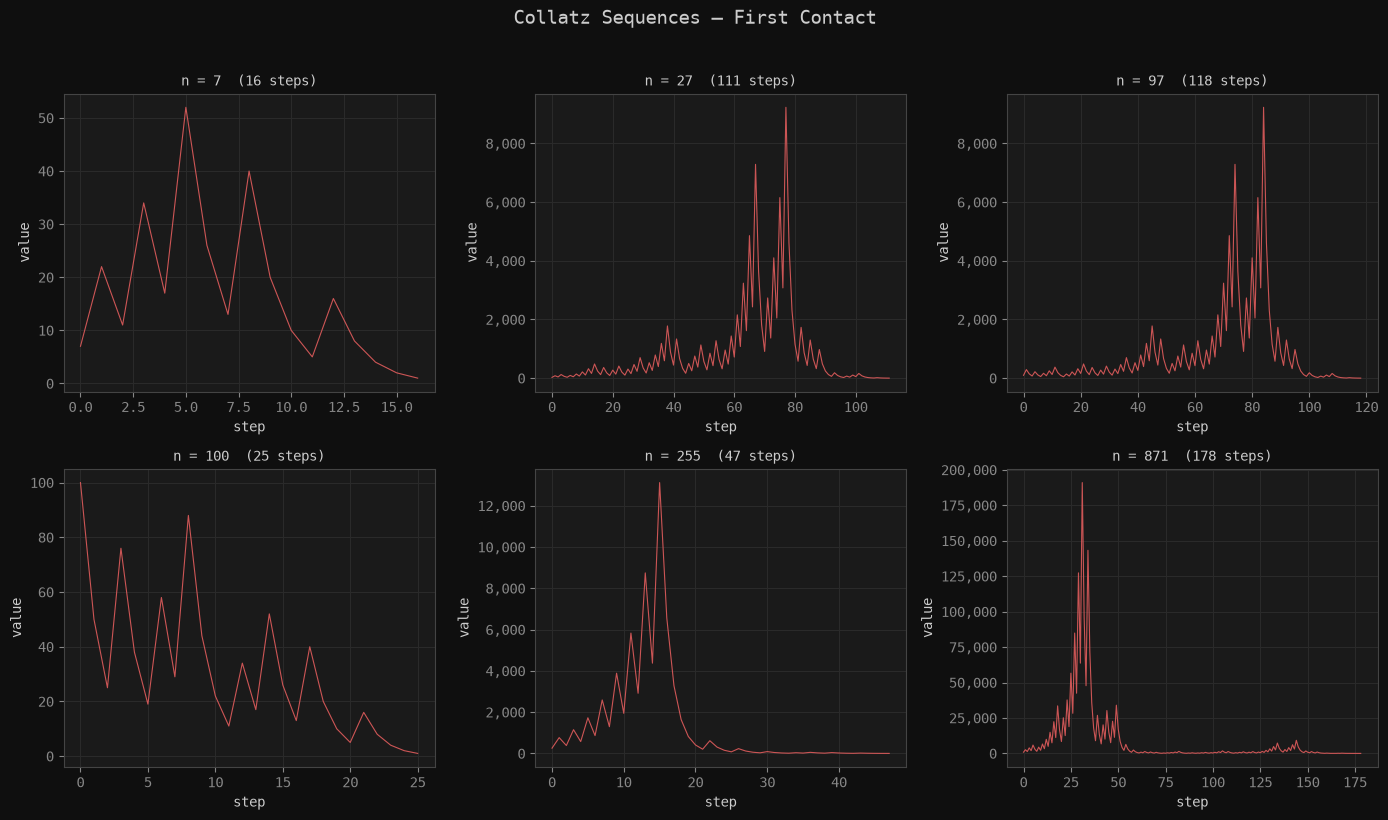

In [4]:
# Plot a few sequences as trajectories
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Collatz Sequences — First Contact', fontsize=14, y=1.02)

starts = [7, 27, 97, 100, 255, 871]

for ax, start in zip(axes.flat, starts):
    seq = collatz_sequence(start)
    ax.plot(seq, color=ACCENT, linewidth=0.8, alpha=0.9)
    ax.set_title(f'n = {start}  ({stopping_time(start)} steps)', fontsize=10)
    ax.set_xlabel('step')
    ax.set_ylabel('value')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('01_sequences.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

### Stopping times across a range

Now I want to zoom out. What does stopping time look like across the first 1,000 integers? I'm not looking for anything specific yet — I just want to see the shape of the data before I start imposing hypotheses on it.

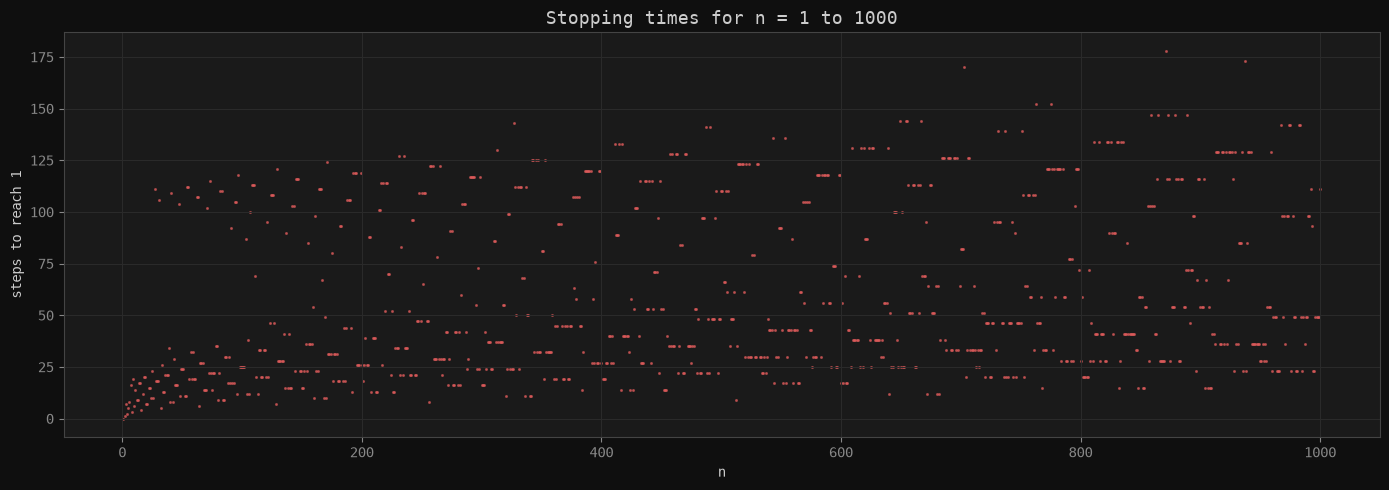

Max stopping time in range: 178 at n=871
Mean stopping time: 59.5


In [5]:
N = 1000
ns = list(range(1, N + 1))
stopping_times = [stopping_time(n) for n in ns]

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(ns, stopping_times, s=1.5, color=ACCENT, alpha=0.6)
ax.set_title(f'Stopping times for n = 1 to {N}', fontsize=13)
ax.set_xlabel('n')
ax.set_ylabel('steps to reach 1')
plt.tight_layout()
plt.savefig('01_stopping_times.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print(f"Max stopping time in range: {max(stopping_times)} at n={ns[stopping_times.index(max(stopping_times))]}")
print(f"Mean stopping time: {np.mean(stopping_times):.1f}")

That scatter plot already raises questions I wasn't expecting to ask. There's clearly *some* structure — the points aren't uniformly random — but the structure is elusive. There are vertical bands that suggest certain regions of $n$ behave similarly, and there are isolated points that shoot up well above their neighbours.

I notice the distribution seems to have a rough upper envelope that grows, but not quickly. That's worth investigating properly in a later notebook.

---

### Stopping time distribution

What does the distribution of stopping times actually look like? Is it roughly normal? Skewed? I don't know, and I shouldn't assume.

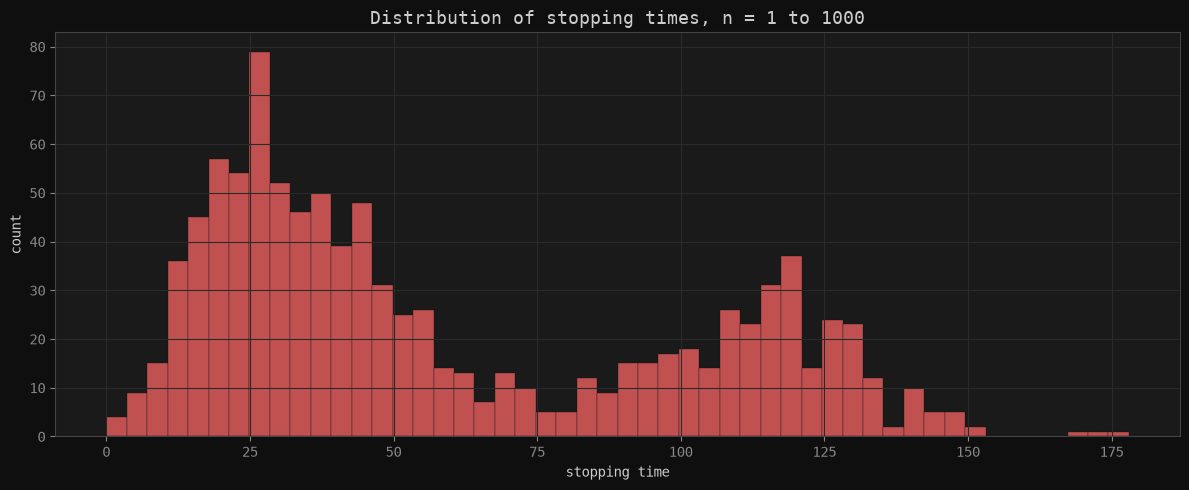

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(stopping_times, bins=50, color=ACCENT, alpha=0.85, edgecolor='#0f0f0f', linewidth=0.3)
ax.set_title(f'Distribution of stopping times, n = 1 to {N}', fontsize=13)
ax.set_xlabel('stopping time')
ax.set_ylabel('count')
plt.tight_layout()
plt.savefig('01_stopping_dist.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

That's roughly unimodal and right-skewed — most numbers reach 1 relatively quickly, but there's a long tail. That shape looks almost log-normal to me, though I'm not going to claim that without testing it properly. That's a thread for a later notebook.

---

### Where I am at the end of Notebook 1

I've stated the problem precisely, implemented the basic machinery, and taken a first look at the data without imposing too much structure on it yet.

A few things are already nagging at me:

1. **The irregularity is real, not an artefact.** $n = 27$ behaving so differently from $n = 26$ and $n = 28$ isn't a fluke — that kind of local chaos appears throughout. Why?

2. **The stopping time distribution has a shape.** It looks right-skewed, possibly log-normal. Whether that has any deep meaning or is just a statistical artefact of how the sequences work is unclear to me.

3. **There seem to be structural bands in the scatter plot.** Some regularity is hiding in there. Powers of 2 might be relevant — they collapse immediately. What else creates the structure?

4. **The function $f$ is asymmetric in an interesting way.** Dividing by 2 reduces $n$; multiplying by 3 and adding 1 increases it *and* makes it even, guaranteeing the next step is a division. That interplay feels important.

**Notebook 2** will investigate stopping times more carefully — their distribution, their relationship to the structure of $n$, and whether anything predictive can be said about them.

---

*Part of the [beautiful-dead-ends](https://github.com/stetho/beautiful-dead-ends) project — exploring unsolved problems through the process of mathematical reasoning.*
